In [1]:
import sys
import json
import logging
import warnings
from pathlib import Path
import matplotlib.pyplot as plt

import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, accuracy_score, mean_squared_error, mean_absolute_error, r2_score
from tqdm import tqdm
from sklearn.preprocessing import OneHotEncoder

warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.INFO, format='%(asctime)s [%(levelname)s] %(message)s')
logger = logging.getLogger(__name__)

In [2]:
# Конфигурация
BASE_DIR = Path.cwd().parent
PROCESSED_DIR = BASE_DIR / "bigdata" / "processed"

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
logger.info(f"Устройство: {DEVICE}")

SEQ_LEN = 40
BATCH_SIZE = 128
EPOCHS = 50
TARGET_CONFIGS = [
    {'type': 'binary', 'col': 'target_binary_20d', 'dir': 'exp4_gru_binary'},
    {'type': 'return', 'col': 'target_return_20d', 'dir': 'exp4_gru_return'}
]
VAL_START = '2022-01-01'
TEST_START = '2023-01-01'

2026-05-26 13:12:20,232 [INFO] Устройство: cuda


In [2]:
# Загрузка данных
df = pd.read_parquet(PROCESSED_DIR / "combined_features.parquet")
with open(PROCESSED_DIR / "feature_columns.txt") as f:
    feature_cols = [line.strip() for line in f if line.strip()]

# Топ-50 тикеров по объёму
top_tickers = df.groupby('ticker')['volume'].mean().sort_values(ascending=False).head(50).index.tolist()
df = df[df['ticker'].isin(top_tickers)].copy()
df_original = df.sort_values(['date', 'ticker']).reset_index(drop=True)

logger.info(f"Данные: {df_original.shape}, тикеров: {df_original['ticker'].nunique()}")

2026-05-23 03:19:25,161 [INFO] Данные: (154766, 124), тикеров: 50


In [3]:
def create_sequences(df, feature_cols, target_col, seq_len, test_start, val_start=None):
    X_train, y_train, X_val, y_val, X_test, y_test = [], [], [], [], [], []
    
    for ticker in df['ticker'].unique():
        ticker_data = df[df['ticker'] == ticker].sort_values('date').copy()
        if len(ticker_data) < seq_len + 10:
            continue
        
        ticker_data[feature_cols] = ticker_data[feature_cols].ffill()
        ticker_data = ticker_data.dropna(subset=feature_cols + [target_col])
        if len(ticker_data) < seq_len + 1:
            continue
        
        # Разделение по датам
        if val_start is not None:
            train_df = ticker_data[ticker_data['date'] < val_start]
            val_df = ticker_data[(ticker_data['date'] >= val_start) & (ticker_data['date'] < test_start)]
        else:
            train_df = ticker_data[ticker_data['date'] < test_start]
            val_df = pd.DataFrame()
        test_df = ticker_data[ticker_data['date'] >= test_start].copy()
        
        if len(train_df) < seq_len + 1:
            continue
        
        # Масштабирование
        scaler = StandardScaler()
        train_scaled = scaler.fit_transform(train_df[feature_cols])
        test_scaled = scaler.transform(test_df[feature_cols])
        
        train_targets = train_df[target_col].values
        test_targets = test_df[target_col].values
        
        # Построение последовательностей для обучения
        for i in range(len(train_scaled) - seq_len):
            X_train.append(train_scaled[i:i+seq_len])
            y_train.append(train_targets[i+seq_len])
        
        # Построение последовательностей для валидации
        if val_start is not None and len(val_df) >= seq_len + 1:
            val_scaled = scaler.transform(val_df[feature_cols])
            val_targets = val_df[target_col].values
            for i in range(len(val_scaled) - seq_len):
                X_val.append(val_scaled[i:i+seq_len])
                y_val.append(val_targets[i+seq_len])
        
        # Построение последовательностей для теста
        for i in range(len(test_scaled) - seq_len):
            X_test.append(test_scaled[i:i+seq_len])
            y_test.append(test_targets[i+seq_len])
    
    if not X_train or not X_test:
        raise ValueError("Не удалось создать последовательности")
    
    return (np.array(X_train, dtype=np.float32), np.array(y_train, dtype=np.float32),
            np.array(X_val, dtype=np.float32) if X_val else np.array([]),
            np.array(y_val, dtype=np.float32) if y_val else np.array([]),
            np.array(X_test, dtype=np.float32), np.array(y_test, dtype=np.float32))

In [ ]:
# Простая GRU модель
class GRUModel(nn.Module):
    def __init__(self, input_dim, hidden_dim=16, num_layers=1, output_dim=1, dropout=0.5):
        super().__init__()
        self.gru = nn.GRU(input_dim, hidden_dim, num_layers, batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_dim, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        out, _ = self.gru(x)
        out = self.dropout(out[:, -1, :])
        return self.fc(out)

    def init_weights(self):
        for name, param in self.gru.named_parameters():
            if 'weight_ih' in name:
                torch.nn.init.xavier_uniform_(param)
            elif 'weight_hh' in name:
                torch.nn.init.orthogonal_(param)
            elif 'bias' in name:
                param.data.fill_(0.01)
        torch.nn.init.xavier_uniform_(self.fc.weight)
        if self.fc.bias is not None:
            self.fc.bias.data.fill_(0.01)

In [ ]:
# Улучшенная GRU модель
class ImprovedGRU(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, num_layers=3, output_dim=1, dropout=0.5, bidirectional=True):
        super().__init__()
        self.gru = nn.GRU(input_dim, hidden_dim, num_layers,
                          batch_first=True, dropout=dropout,
                          bidirectional=bidirectional)
        self.bn = nn.BatchNorm1d(hidden_dim * (2 if bidirectional else 1))
        self.fc = nn.Linear(hidden_dim * (2 if bidirectional else 1), output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        out, _ = self.gru(x)
        out = out[:, -1, :]
        out = self.bn(out)
        out = self.dropout(out)
        return self.fc(out)

2026-05-23 03:19:29,379 [INFO] Train: (116815, 40, 109), Val: (7132, 40, 109), Test: (13907, 40, 109)
Epoch 1: 100%|██████████| 913/913 [00:03<00:00, 239.20it/s]
2026-05-23 03:19:33,743 [INFO] Epoch 1: train_loss=0.7122, val_loss=0.7064, val_auc=0.5411
Epoch 2: 100%|██████████| 913/913 [00:03<00:00, 250.72it/s]
2026-05-23 03:19:37,405 [INFO] Epoch 2: train_loss=0.6549, val_loss=0.7220, val_auc=0.5365
Epoch 3: 100%|██████████| 913/913 [00:03<00:00, 270.44it/s]
2026-05-23 03:19:40,793 [INFO] Epoch 3: train_loss=0.6232, val_loss=0.7204, val_auc=0.5443
Epoch 4: 100%|██████████| 913/913 [00:03<00:00, 269.39it/s]
2026-05-23 03:19:44,217 [INFO] Epoch 4: train_loss=0.5964, val_loss=0.7449, val_auc=0.5206
Epoch 5: 100%|██████████| 913/913 [00:03<00:00, 269.30it/s]
2026-05-23 03:19:47,622 [INFO] Epoch 5: train_loss=0.5777, val_loss=0.7631, val_auc=0.5169
Epoch 6: 100%|██████████| 913/913 [00:03<00:00, 275.40it/s]
2026-05-23 03:19:50,952 [INFO] Epoch 6: train_loss=0.5615, val_loss=0.7702, val_auc

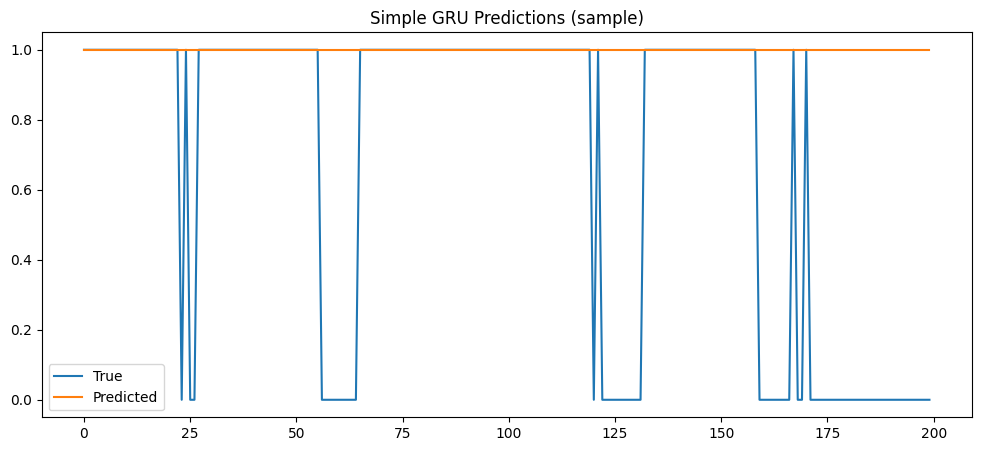

Improved Epoch 1: 100%|██████████| 913/913 [00:12<00:00, 75.50it/s]
2026-05-23 03:20:11,727 [INFO] Improved Epoch 1: train_loss=0.6524, val_loss=0.8913, val_auc=0.4286
Improved Epoch 2: 100%|██████████| 913/913 [00:12<00:00, 76.02it/s]
2026-05-23 03:20:25,011 [INFO] Improved Epoch 2: train_loss=0.5496, val_loss=1.0558, val_auc=0.4047
Improved Epoch 3: 100%|██████████| 913/913 [00:12<00:00, 75.78it/s]
2026-05-23 03:20:38,327 [INFO] Improved Epoch 3: train_loss=0.4682, val_loss=1.1679, val_auc=0.4258
Improved Epoch 4: 100%|██████████| 913/913 [00:12<00:00, 75.34it/s]
2026-05-23 03:20:51,711 [INFO] Improved Epoch 4: train_loss=0.4022, val_loss=1.3459, val_auc=0.4032
Improved Epoch 5: 100%|██████████| 913/913 [00:12<00:00, 74.66it/s]
2026-05-23 03:21:05,205 [INFO] Improved Epoch 5: train_loss=0.3540, val_loss=1.3909, val_auc=0.4220
Improved Epoch 6: 100%|██████████| 913/913 [00:12<00:00, 74.88it/s]
2026-05-23 03:21:18,662 [INFO] Improved Epoch 6: train_loss=0.2894, val_loss=1.5797, val_auc

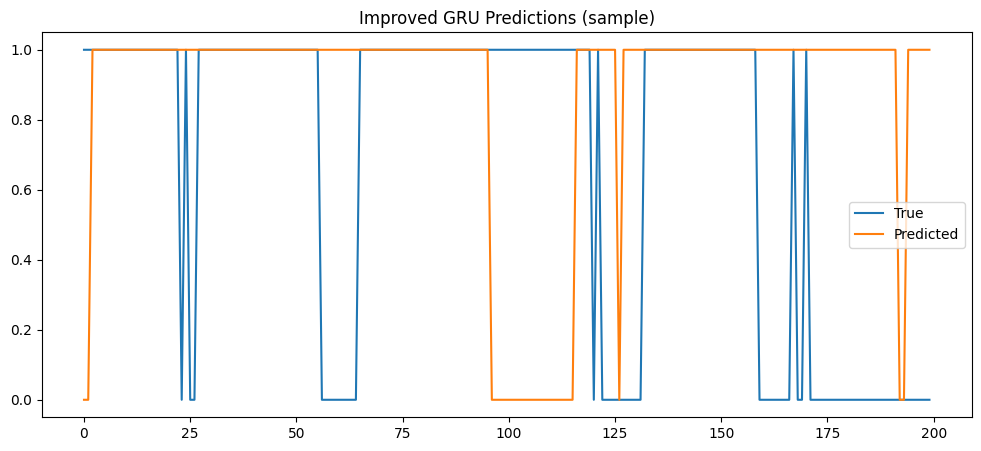

2026-05-23 03:21:22,036 [INFO] Эксперимент 3 (GRU) для binary завершён.
2026-05-23 03:21:24,865 [INFO] Train: (116815, 40, 109), Val: (7132, 40, 109), Test: (13167, 40, 109)
Epoch 1: 100%|██████████| 913/913 [00:03<00:00, 270.22it/s]
2026-05-23 03:21:28,909 [INFO] Epoch 1: train_loss=0.2519, val_loss=0.2553
Epoch 2: 100%|██████████| 913/913 [00:03<00:00, 262.78it/s]
2026-05-23 03:21:32,397 [INFO] Epoch 2: train_loss=0.1798, val_loss=0.2550
Epoch 3: 100%|██████████| 913/913 [00:03<00:00, 278.67it/s]
2026-05-23 03:21:35,688 [INFO] Epoch 3: train_loss=0.1682, val_loss=0.2452
Epoch 4: 100%|██████████| 913/913 [00:03<00:00, 276.59it/s]
2026-05-23 03:21:39,006 [INFO] Epoch 4: train_loss=0.1593, val_loss=0.2413
Epoch 5: 100%|██████████| 913/913 [00:03<00:00, 280.32it/s]
2026-05-23 03:21:42,279 [INFO] Epoch 5: train_loss=0.1516, val_loss=0.2524
Epoch 6: 100%|██████████| 913/913 [00:03<00:00, 283.15it/s]
2026-05-23 03:21:45,519 [INFO] Epoch 6: train_loss=0.1449, val_loss=0.2557
Epoch 7: 100%|██

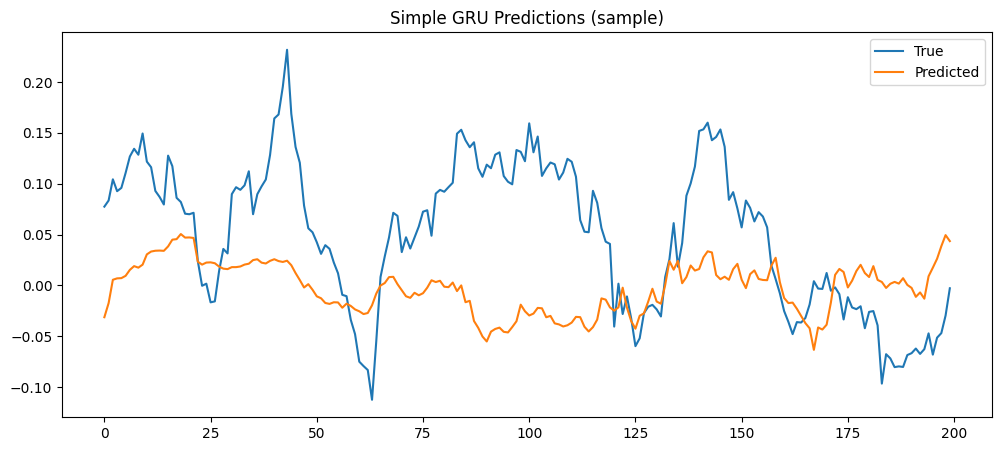

Improved Epoch 1: 100%|██████████| 913/913 [00:12<00:00, 74.76it/s]
2026-05-23 03:22:08,911 [INFO] Improved Epoch 1: train_loss=0.1872, val_loss=0.3783
Improved Epoch 2: 100%|██████████| 913/913 [00:12<00:00, 75.72it/s]
2026-05-23 03:22:22,332 [INFO] Improved Epoch 2: train_loss=0.1374, val_loss=0.3241
Improved Epoch 3: 100%|██████████| 913/913 [00:12<00:00, 75.54it/s]
2026-05-23 03:22:35,790 [INFO] Improved Epoch 3: train_loss=0.1121, val_loss=0.3007
Improved Epoch 4: 100%|██████████| 913/913 [00:12<00:00, 74.38it/s]
2026-05-23 03:22:49,440 [INFO] Improved Epoch 4: train_loss=0.0915, val_loss=0.3265
Improved Epoch 5: 100%|██████████| 913/913 [00:12<00:00, 74.06it/s]
2026-05-23 03:23:03,125 [INFO] Improved Epoch 5: train_loss=0.0767, val_loss=0.3068
Improved Epoch 6: 100%|██████████| 913/913 [00:12<00:00, 73.13it/s]
2026-05-23 03:23:16,959 [INFO] Improved Epoch 6: train_loss=0.0675, val_loss=0.3262
Improved Epoch 7: 100%|██████████| 913/913 [00:12<00:00, 72.99it/s]
2026-05-23 03:23:30,

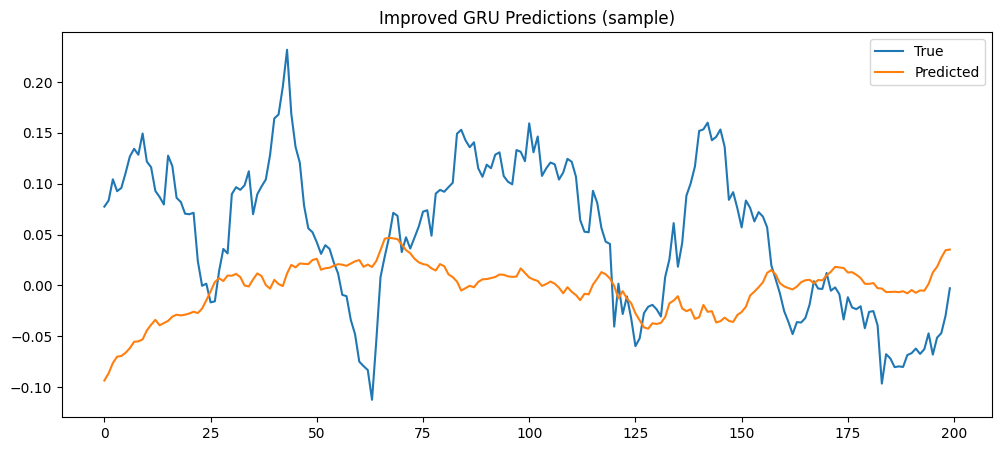

2026-05-23 03:23:47,521 [INFO] Эксперимент 3 (GRU) для return завершён.


In [ ]:
# Обучение и оценка моделей
for cfg in TARGET_CONFIGS:
    TARGET_TYPE = cfg['type']
    TARGET_COL = cfg['col']
    ARTIFACTS_DIR = BASE_DIR / "artifacts" / cfg['dir']
    ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

    model = GRUModel(input_dim=len(feature_cols)).to(DEVICE)
    model.init_weights()

    if TARGET_TYPE == 'binary':
        criterion = nn.BCEWithLogitsLoss()
    else:
        criterion = nn.HuberLoss(delta=1.0)
    optimizer = torch.optim.AdamW(model.parameters(), lr=0.0005, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3)

    df = df_original.copy()
    df = df.dropna(subset=[TARGET_COL])
    X_train, y_train, X_val, y_val, X_test, y_test = create_sequences(
        df, feature_cols, TARGET_COL, SEQ_LEN, TEST_START, val_start=VAL_START
    )

    # Нормализация таргета для регрессии
    if TARGET_TYPE == 'return':
        y_scaler = StandardScaler()
        y_train = y_scaler.fit_transform(y_train.reshape(-1, 1)).flatten()
        if len(y_val) > 0:
            y_val = y_scaler.transform(y_val.reshape(-1, 1)).flatten()

    logger.info(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

    dataset = TensorDataset(torch.tensor(X_train).to(DEVICE), torch.tensor(y_train).to(DEVICE))
    loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

    best_loss = float('inf')
    patience = 5
    counter = 0

    X_val_t = torch.tensor(X_val).to(DEVICE)
    y_val_t = torch.tensor(y_val).to(DEVICE)

    best_auc = -np.inf
    for epoch in range(EPOCHS):
        model.train()
        total_loss = 0
        for batch_x, batch_y in tqdm(loader, desc=f'Epoch {epoch+1}'):
            optimizer.zero_grad()
            pred = model(batch_x).squeeze()
            loss = criterion(pred, batch_y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            total_loss += loss.item()
        avg_loss = total_loss / len(loader)

        model.eval()
        with torch.no_grad():
            val_pred = model(X_val_t).squeeze()
            val_loss = criterion(val_pred, y_val_t).item()
            if TARGET_TYPE == 'binary':
                val_proba = torch.sigmoid(val_pred).cpu().numpy()
                val_auc = roc_auc_score(y_val, val_proba)
            else:
                val_auc = -val_loss   # fallback

        # Сохраняем лучшую модель по AUC
        if TARGET_TYPE == 'binary':
            logger.info(f"Epoch {epoch+1}: train_loss={avg_loss:.4f}, val_loss={val_loss:.4f}, val_auc={val_auc:.4f}")
            if val_auc > best_auc:
                best_auc = val_auc
                torch.save(model.state_dict(), ARTIFACTS_DIR / 'best_gru.pt')
                counter = 0
            else:
                counter += 1
                if counter >= patience:
                    logger.info(f"Early stopping на эпохе {epoch+1}")
                    break
        else:
            # для регрессии оставляем loss
            logger.info(f"Epoch {epoch+1}: train_loss={avg_loss:.4f}, val_loss={val_loss:.4f}")
            if val_loss < best_loss:
                best_loss = val_loss
                torch.save(model.state_dict(), ARTIFACTS_DIR / 'best_gru.pt')
                counter = 0
            else:
                counter += 1
                if counter >= patience:
                    logger.info(f"Early stopping на эпохе {epoch+1}")
                    break
        scheduler.step(val_loss)

    # Тестирование простой GRU
    model.load_state_dict(torch.load(ARTIFACTS_DIR / 'best_gru.pt'))
    model.eval()
    with torch.no_grad():
        X_test_t = torch.tensor(X_test).to(DEVICE)
        y_pred_logits = model(X_test_t).squeeze().cpu().numpy()

    if TARGET_TYPE == 'binary':
        y_pred_proba = 1 / (1 + np.exp(-y_pred_logits))
        y_pred = (y_pred_proba >= 0.5).astype(int)
        metrics = {
            'accuracy': accuracy_score(y_test, y_pred),
            'auc': roc_auc_score(y_test, y_pred_proba),
        }
    else:
        y_pred_logits = y_scaler.inverse_transform(y_pred_logits.reshape(-1, 1)).flatten()
        metrics = {
            'rmse': np.sqrt(mean_squared_error(y_test, y_pred_logits)),
            'mae': mean_absolute_error(y_test, y_pred_logits),
            'r2': r2_score(y_test, y_pred_logits)
        }

    logger.info(f"Результаты простой GRU: {metrics}")
    with open(ARTIFACTS_DIR / 'metrics_simple.json', 'w') as f:
        json.dump(metrics, f, indent=2, default=str)

    # График для простой GRU
    plt.figure(figsize=(12,5))
    plt.plot(y_test[:200], label='True')
    if TARGET_TYPE == 'binary':
        plt.plot(y_pred[:200], label='Predicted')
    else:
        plt.plot(y_pred_logits[:200], label='Predicted')
    plt.legend()
    plt.title('Simple GRU Predictions (sample)')
    plt.savefig(ARTIFACTS_DIR / 'predictions_sample_simple.png', dpi=150)
    plt.show()

    model_imp = ImprovedGRU(input_dim=len(feature_cols)).to(DEVICE)
    optimizer_imp = torch.optim.AdamW(model_imp.parameters(), lr=0.0005, weight_decay=1e-5)
    scheduler_imp = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_imp, patience=3)

    best_loss_imp = float('inf')
    counter_imp = 0
    best_auc_imp = -np.inf

    for epoch in range(EPOCHS):
        model_imp.train()
        total_loss = 0
        for batch_x, batch_y in tqdm(loader, desc=f'Improved Epoch {epoch+1}'):
            optimizer_imp.zero_grad()
            pred = model_imp(batch_x).squeeze()
            loss = criterion(pred, batch_y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model_imp.parameters(), max_norm=1.0)
            optimizer_imp.step()
            total_loss += loss.item()
        avg_loss = total_loss / len(loader)

        model_imp.eval()
        with torch.no_grad():
            val_pred = model_imp(X_val_t).squeeze()
            val_loss = criterion(val_pred, y_val_t).item()
            if TARGET_TYPE == 'binary':
                val_proba = torch.sigmoid(val_pred).cpu().numpy()
                val_auc = roc_auc_score(y_val, val_proba)
            else:
                val_auc = -val_loss

        if TARGET_TYPE == 'binary':
            logger.info(f"Improved Epoch {epoch+1}: train_loss={avg_loss:.4f}, val_loss={val_loss:.4f}, val_auc={val_auc:.4f}")
            if val_auc > best_auc_imp:
                best_auc_imp = val_auc
                torch.save(model_imp.state_dict(), ARTIFACTS_DIR / 'best_gru_improved.pt')
                counter_imp = 0
            else:
                counter_imp += 1
                if counter_imp >= patience:
                    logger.info(f"Early stopping на эпохе {epoch+1}")
                    break
        else:
            logger.info(f"Improved Epoch {epoch+1}: train_loss={avg_loss:.4f}, val_loss={val_loss:.4f}")
            if val_loss < best_loss_imp:
                best_loss_imp = val_loss
                torch.save(model_imp.state_dict(), ARTIFACTS_DIR / 'best_gru_improved.pt')
                counter_imp = 0
            else:
                counter_imp += 1
                if counter_imp >= patience:
                    logger.info(f"Early stopping на эпохе {epoch+1}")
                    break
        scheduler_imp.step(val_loss)

    # Тестирование улучшенной GRU
    model_imp.load_state_dict(torch.load(ARTIFACTS_DIR / 'best_gru_improved.pt'))
    model_imp.eval()
    with torch.no_grad():
        y_pred_logits_imp = model_imp(X_test_t).squeeze().cpu().numpy()

    if TARGET_TYPE == 'binary':
        y_pred_proba_imp = 1 / (1 + np.exp(-y_pred_logits_imp))
        y_pred_imp = (y_pred_proba_imp >= 0.5).astype(int)
        metrics_imp = {
            'accuracy': accuracy_score(y_test, y_pred_imp),
            'auc': roc_auc_score(y_test, y_pred_proba_imp),
        }
    else:
        y_pred_logits_imp = y_scaler.inverse_transform(y_pred_logits_imp.reshape(-1, 1)).flatten()
        metrics_imp = {
            'rmse': np.sqrt(mean_squared_error(y_test, y_pred_logits_imp)),
            'mae': mean_absolute_error(y_test, y_pred_logits_imp),
            'r2': r2_score(y_test, y_pred_logits_imp)
        }

    logger.info(f"Результаты улучшенной GRU: {metrics_imp}")
    with open(ARTIFACTS_DIR / 'metrics_improved.json', 'w') as f:
        json.dump(metrics_imp, f, indent=2, default=str)

    # График для улучшенной GRU
    plt.figure(figsize=(12,5))
    plt.plot(y_test[:200], label='True')
    if TARGET_TYPE == 'binary':
        plt.plot(y_pred_imp[:200], label='Predicted')
    else:
        plt.plot(y_pred_logits_imp[:200], label='Predicted')
    plt.legend()
    plt.title('Improved GRU Predictions (sample)')
    plt.savefig(ARTIFACTS_DIR / 'predictions_sample_improved.png', dpi=150)
    plt.show()

    logger.info(f"Эксперимент 3 (GRU) для {TARGET_TYPE} завершён.")